In [203]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from numpy import random
import matplotlib as mpl
# import timeit
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter
import math

pi = np.pi

## Histogram and isotropy

When determining if a distribution is isotropic (evenly distributed) in a sphere, the easiest coordinate system to use is the spherical one: $r, \theta, \phi$ or the radial, polar, and azimuthal coordinates respectively. However, it's not as simple as determining whether the distribution is even in those coordinates. One must instead use the Jacobian $drd\phi d\theta \sin(\theta)$ and see whether it is even in that measure. If one only cares about the polar angle, then a histogram of $d\theta\sin(\theta)$ will suffice; typically, it's easier if, using calculus rules, one switches to $-d\cos(\theta)$ (where the minus is only there for accuracy, not necessity) and essentially determines whether that is even from -1 to +1. 

Below I've put a simple demonstration of how important this process is to determining isotropy. Since the data is random, it might require a re-run to see what the comments suggest. 

In [204]:
def theta_histogram(thetas, bins='auto'):
    '''
    Purpose: To determine isotropy from histogram of cos(theta)
    
    Inputs: 
        thetas: 1D list of theta values. 
        bins: histogram bin input. Default allows np.histogram to choose instead
    '''
    cos_thetas = np.cos(thetas)
    hist, bins = np.histogram(cos_thetas, bins)
    plt.hist(np.cos(thetas), bins=bins, density=True) #type: ignore
    plt.xlabel(fr'$\cos(\theta)$'); plt.ylabel('Count (normalized)')

In [205]:
thetas = 2.*pi*random.rand(500)
thetas_iso = np.arccos(2.*np.random.rand(500)-1.)

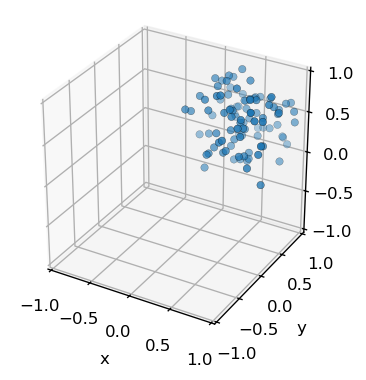

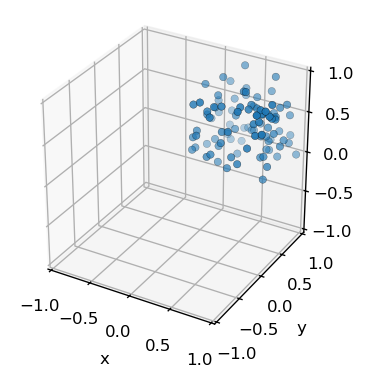

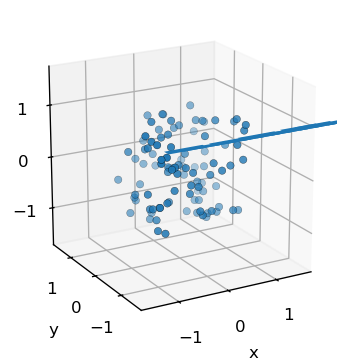

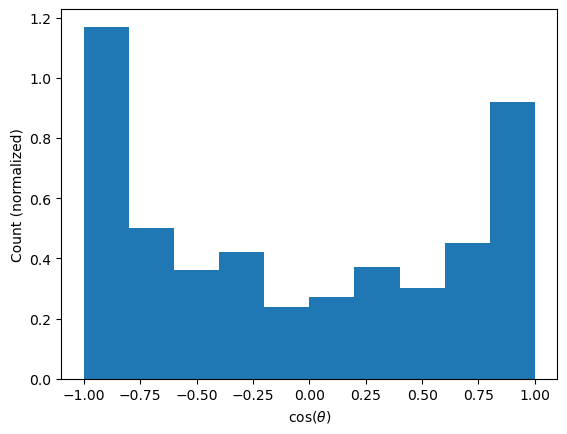

In [206]:
#Originally roughly isotropic turns into very anisotropic (bias towards poles)
plt.hist(thetas, density=True, bins=20)
plt.show()
theta_histogram(thetas)

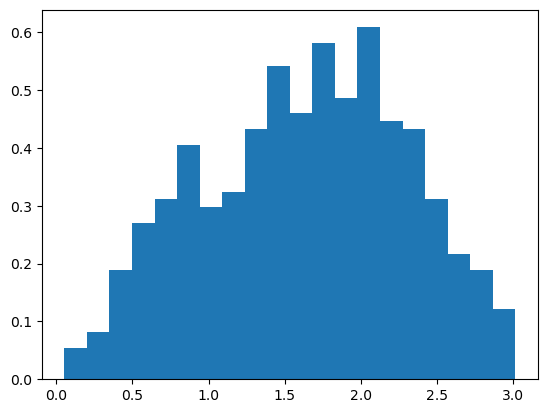

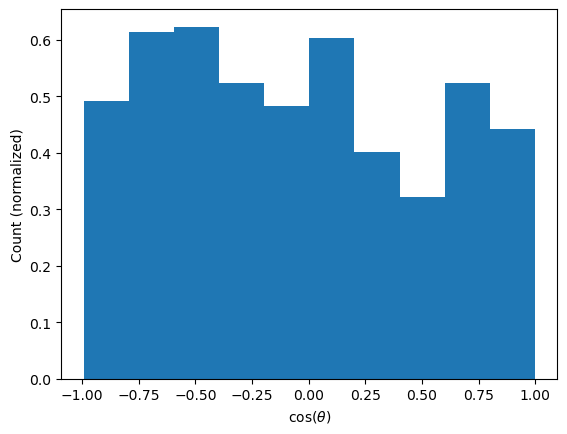

In [207]:
#Originally anisotropic turns into roughly isotropic
plt.hist(thetas_iso, density=True, bins=20)
plt.show()
theta_histogram(thetas_iso)

## Polar Plotter

In [208]:
def polar_plotter(radiusList, thetaList, points, angTerm):
    '''
    Purpose: To plot a polar heat map of particles over time. Can also be used to plot a distribution \
    of particles in a snapshot
    
    Input:
        radiusList: flattened list of radii from particles originally in the shape (timestep, particle)
        thetaList: flattened list of thetas from particles originally in the shape (timestep, particle)
        points: number of grids for both r and theta
        angTerm: tuple of terminated polar angle (radian_end, degree_end). For circle, (2pi, 360), \
        and half circle (pi, 180). Degrees must be integers
    '''
    r_min = min(radiusList); r_max = max(radiusList)
    angle_end, deg = angTerm
    #Figure setup
    fig, axes = plt.subplots(subplot_kw={'projection': 'polar'})
    fig.set_figwidth(6); fig.set_figheight(6);
    axes.set_theta_direction(-1)
    axes.set_theta_offset(np.pi / 2.) 
    axes.set_rlabel_position(0) 
    axes.set_thetamax(deg)
    #Creating grid, calculating count of each gridpoint
    radius = np.linspace(r_min, r_max, points)
    angle = np.linspace(0, angle_end, points)
    H, binsx, binsy = np.histogram2d(radiusList, thetaList, bins=(radius, angle))
    rad, ang = np.meshgrid(radius, angle)
    #Plotting
    rlabels = axes.get_ymajorticklabels()
    [label.set_color('white') for label in rlabels]
    plt.pcolormesh(ang, rad, H, shading='auto')
    plt.thetagrids(range(0, deg, 15))
    axes.set_title(f'Particles',fontsize=15)
    axes.grid(color='grey',alpha=0.5)
    axes.grid(True)
    plt.colorbar(label=f'# of particles', pad=0.1)
    plt.show()

In [209]:
radiusL = np.random.rand(100, 50).flatten()
thetasL = 2.*pi*np.random.rand(100, 50).flatten()
pts = 100

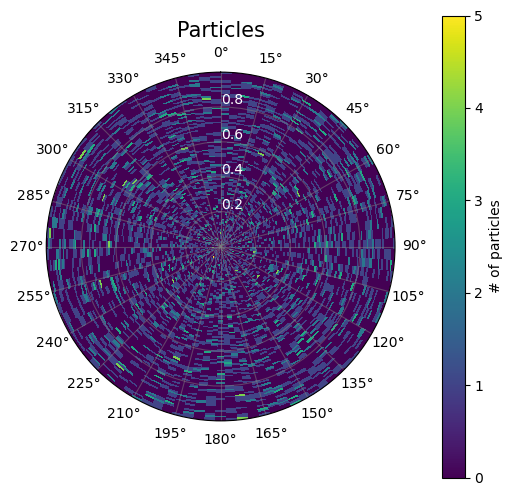

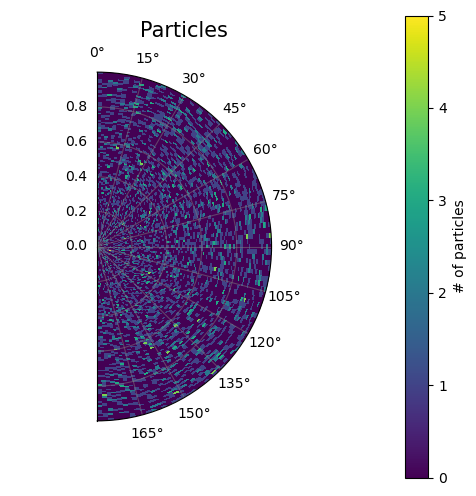

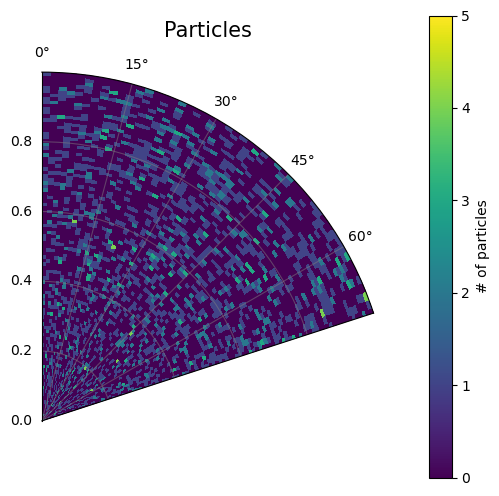

In [210]:
polar_plotter(radiusL, thetasL, pts, (2.*pi, 360))
polar_plotter(radiusL, thetasL/2., pts, (pi, 180))
polar_plotter(radiusL, thetasL/2.5, pts, (2.*pi/2.5, int(180/2.5)))

## Animation & 3D Plotting

### 2D Animation

In [211]:
def animate_2Ddata(xData, yData, labels, axisLims=[], frameCount=-1, dynm_lims=False):
    '''
    Purpose: Animate 2D plots of data. 
    Input:
        xData: array of x-value data from particles in the shape (timestep, particle)
        yData: array of y-value data from particles in the shape (timestep, particle)
        labels: list of x/y axis labels in the form [x-axis label, y-axis label]
        axisLims: list of axis limits in the form [xmin, xmax, ymin, ymax]. Optional
        frameCount: how much of the timesteps to plot, default is all of them. Optional
        dynm_lims: semi-dynamic axis limits, based on x/y maxima per time step. Optional
    Return:
        ani: animation.FuncAnimation object
    '''
    if(frameCount == -1): frameCount = len(xData)-1
    xData = xData[0:frameCount]; yData = yData[0:frameCount]
    #Setup
    fig, ax = plt.subplots()
    if(axisLims != []): ax.axis(axisLims) #graph limits
    ax.set_xlabel(labels[0]); ax.set_ylabel(labels[1])
    ax.set_title(fr'Particles',fontsize=14)

    #First frame setup
    l = ax.scatter([],[],)
    l.set_sizes(np.ones(1))

    axisLims0 = [1.001*max(x) for x in xData]
    axisLims1 = [1.2*max(y) for y in yData]

    def animate(i): #Makes ith plot image
        l.set_offsets(np.array([xData[i], yData[i]]).transpose())
        ax.set_title(fr'Particles, timestep {i}',fontsize=14)
        if(dynm_lims): ax.axis([axisLims[0], axisLims0[i], axisLims[2], axisLims1[i]])

    ani = animation.FuncAnimation(fig, animate, frames=len(xData), interval=20) # type: ignore
    plt.close() #To prevent extra plot image from showing up
    return ani

In [212]:
xData = np.random.rand(100, 50)
yData = np.random.rand(100, 50)
labels = [r'$x$ particles (arbitrary)', r'$y$ particles (arbitrary)']
xmax = max(map(max, xData)); xmin = min(map(min, xData))
ymax = max(map(max, yData)); ymin = min(map(min, yData))
axLims=[xmin, xmax, ymin, ymax]
ani = animate_2Ddata(xData, yData, labels, axLims)
#To see the animation in-notebook, takes longer to run
HTML(ani.to_jshtml())
#To save animation
# Writer = animation.writers['ffmpeg']
# writer = Writer(fps=30, metadata = {'artist': 'Me'}, bitrate=750)
# ani.save('plotname.mp4', writer)

### Animated Histogram

In [213]:
def animate_hist(histData):
    '''
    Purpose: To produce an animated series of histograms
    
    Inputs: 
        histData: array of data values in the shape (timestep, value)
    '''
    numFrames = len(histData)
    fig = plt.figure()
    hist = plt.hist(histData[0], bins=50)

    def update_hist(num, histData):
        plt.cla()
        plt.hist(histData[num], density=True)
        plt.title(fr'Particle histogram, timestep {num}',fontsize=14)
        # plt.xlabel(fr'$\cos(\theta_k)$')
        plt.xlabel(fr'$\cos(\theta)$')
        plt.ylabel('Count (normalized)')

    ani = animation.FuncAnimation(fig, update_hist, numFrames, fargs=(histData,),interval=100)
    return ani

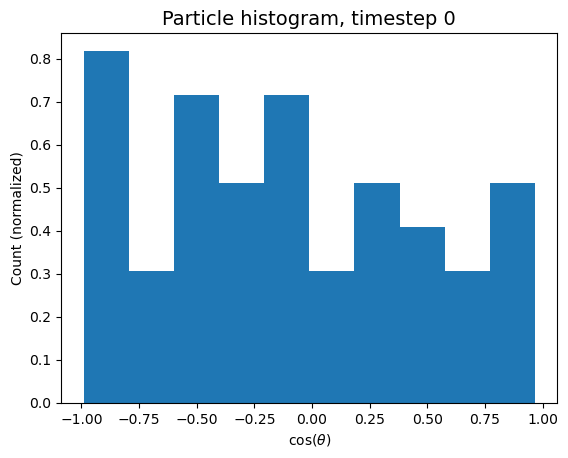

In [214]:
histData = 2.*np.random.rand(100, 50)-1.
ani = animate_hist(histData)
#To see the animation in-notebook, takes longer to run
HTML(ani.to_jshtml())
#To save animation
# Writer = animation.writers['ffmpeg']
# writer = Writer(fps=30, metadata = {'artist': 'Me'}, bitrate=750)
# ani.save('plotname.mp4', writer)

### Animated 3D Plot with color values

0.0
0.12578616352201258
0.25157232704402516
0.37735849056603776
0.5031446540880503
0.6289308176100629
0.7547169811320755
0.8805031446540881
1.0062893081761006
1.1320754716981132
1.2578616352201257
1.3836477987421383
1.509433962264151
1.6352201257861636
1.7610062893081762
1.8867924528301887
2.0125786163522013
2.138364779874214
2.2641509433962264
2.389937106918239
2.5157232704402515
2.641509433962264
2.7672955974842766
2.893081761006289
3.018867924528302
3.1446540880503147
3.270440251572327
3.3962264150943398
3.5220125786163523
3.647798742138365
3.7735849056603774
3.89937106918239
4.0251572327044025
4.150943396226415
4.276729559748428
4.40251572327044
4.528301886792453
4.654088050314465
4.779874213836478
4.90566037735849
5.031446540880503
5.1572327044025155
5.283018867924528
5.408805031446541
5.534591194968553
5.660377358490566
5.786163522012578
5.911949685534591
6.037735849056604
6.163522012578617
6.289308176100629
6.415094339622642
6.540880503144654
6.666666666666667
6.7924528301886795

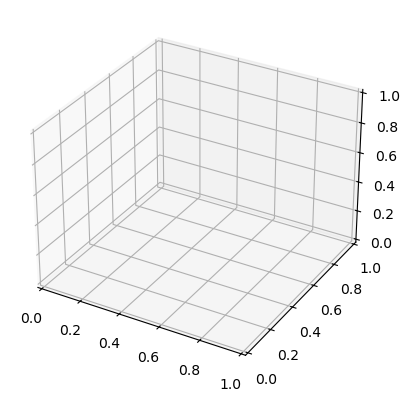

In [215]:
#Example I found online
from matplotlib import cm
from matplotlib.animation import FFMpegWriter

# Fixing random state for reproducibility
np.random.seed(19680801)

metadata = dict(title='Movie', artist='codinglikemad')
writer = FFMpegWriter(fps=15, metadata=metadata)

fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))
plt.xlim(-5, 5)
plt.ylim(-5, 5)

def func(x,y,r,t):
    return np.cos(r/2+t)*np.exp(-np.square(r)/50)

xvec = np.linspace(-10, 10, 1000)
yvec = np.linspace(-10, 10, 1000)
xlist, ylist = np.meshgrid(xvec, yvec)
rlist = np.sqrt( np.square(xlist) + np.square(ylist) )

with writer.saving(fig, "exp3d.mp4", 100):
    for tval in np.linspace(0,20,160):
        print(tval)
        zval = func(xlist,ylist,rlist, tval)
        ax.set_zlim(-1, 1)
        ax.plot_surface(xlist,ylist,zval,cmap=cm.viridis)
        writer.grab_frame()
        plt.cla()

### Animated 3D Plot with rotation

In [216]:
def make3Dmovie(xyzPlotter, fname, scale, colorVals, unitLbl='arbitrary', Disk=False):
    '''
    Purpose: Animate 3D plots of data with colorbar, rotating frame

    Input:
        xyzPlotter: list of (xData, yData, zData), each in the shape (timestep, particle)
        fname: file name you want to save animation as
        scale: how much the axis values will be scaled by
        colorVals: the value a particle has at a given timestep, in shape (timestep, particle)
        unitLbl: the unit of your scale. Optional
        disk: boolean that dictates if the boundaries of a cylinder are drawn. Optional
    '''
    xPlotter, yPlotter, zPlotter = xyzPlotter
    metadata = dict(title='Movie', artist='AB')
    writer = FFMpegWriter(fps=30, metadata=metadata)
    height = 0.5

    fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))

    time_len = len(xPlotter)
    cmap = 'plasma'
    def setlims(L, i):
        lims = [-L, L]
        ax.tick_params(axis='x', labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='z', labelsize=8)
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_zlim(lims)
        expo = scale #int(np.log10(scale)) #if values are large, use latter
        label = f"{expo:.0f} {unitLbl}" #f"1e{expo:.0f} {unitLbl}" #same here
        ax.set_xlabel(fr'x [{label}]', fontsize=10)
        ax.set_ylabel(fr'y [{label}]', fontsize=10)
        ax.set_zlabel(fr'z [{label}]', fontsize=10)
        ax.view_init(elev=30., azim = i/4)
    
    def colormap(i, data, p):
        color_i = colorVals[i] #np.log10(colorVals[i]) #if values are larger, use latter
        p = ax.scatter(*data, c=color_i, cmap=cmap, s=0.5)
        p.set_array(color_i)

    def disk():
        if(not Disk): return
        pts = 200; phi = np.linspace(0,2*np.pi,pts)
        ax.plot(np.cos(phi), np.sin(phi), height,linestyle='solid',color='black',linewidth=1)
        ax.plot(np.cos(phi), np.sin(phi), -height,linestyle='solid',color='black',linewidth=1)

    fac = abs(min(xPlotter[0])/scale)
    with writer.saving(fig, f"{fname}.mp4", dpi=100):
        #breaks would signify which timesteps to put pauses, and pauses how many frames a pause lasts
        # breaks = np.array([0, 100, 200, 300, 400, 500])
        # pauses = np.array([4, 4, 3, 2, 1, 1])

        p = ax.scatter(xPlotter[0],yPlotter[0],zPlotter[0], c=np.log10(colorVals[0]), 
            cmap=cmap, s=0.5)
        cbar = fig.colorbar(p, pad=0.1)
        cbar.set_label(r'color value')
        # cbar.set_label(r'$\log_{10}(color value)$') #for larger values

        for tval in range(time_len):
            print(tval)
            ax.set_title(fr'Particles, timestep {tval}',fontsize=14)
            xs, ys, zs = xPlotter[tval],yPlotter[tval],zPlotter[tval]
            fac = max(max(xs/scale), fac)
            setlims(fac, tval); disk()
            data = xs/scale, ys/scale, zs/scale
            
            #Color bar stuff
            colormap(tval, data, p)
            # #Slowing down near important parts
            # pause_i = range(pauses[breaks <= tval][-1]) #controls how long
            # [writer.grab_frame() for i in pause_i]      #the 'pause' lasts
            writer.grab_frame()
            plt.cla()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


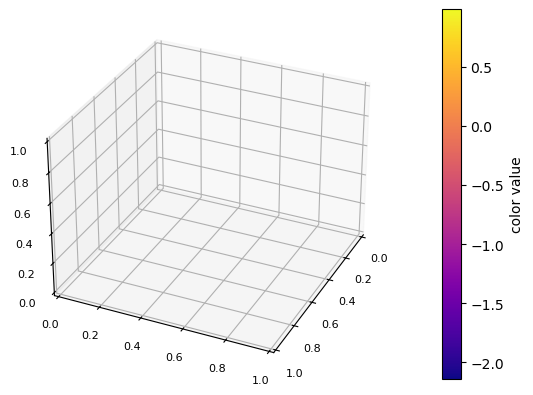

In [217]:
xData = 2.*np.random.rand(100, 50)-1
yData = 2.*np.random.rand(100, 50)-1
zData = 2.*np.random.rand(100, 50)-1
cvals = 10.*np.random.rand(100, 50)
make3Dmovie((xData, yData, zData), 'fileName', 1, cvals)

### Plotting 3D 

Making 3D plots in Jupyter notebooks (and specifically in VS Code), it's easy to zoom in/out, move the location, save the figure manually, etc. However, you need to put `%matplotlib widget` or else the aforementioned benefits won't apply. It can also be annoying to plot regularly afterward, since you need to include `%matplotlib inline` to prevent weird plotting errors; hence why I saved this for last. 

In [218]:
def plot_3D(x, y, z, Lrange,figsize=(5,3.5)):
    '''
    Purpose: A function to plot a particle's path on a 3D, interactive graph

    Input: 
        Lrange: A (3,2) shape list containing the ranges of x,y, and z such that Lrange = [[x_min, x_max],[y_min, y_max],[z_min, z_max]]
        figsize: The figure size. Default is (10,10)
    Returns: plt.figure output ("ax"). 
    '''
    ax = plt.figure(figsize=figsize).add_subplot(projection='3d')
    # ax.plot(x, y, z,'o',markersize=5,edgecolors='k')
    ax.scatter(x, y, z,edgecolors='k',linewidths=2/10)    
    ax.set_xlabel(f'x'); ax.set_ylabel(f'y'); ax.set_zlabel(f'z')
    ax.set_xlim(Lrange[0][0],Lrange[0][1]); ax.set_ylim(Lrange[1][0],Lrange[1][1]); ax.set_zlim(Lrange[2][0],Lrange[2][1])
    ax.set_aspect('equal')
    return ax

In [219]:
x = 2.*np.random.rand(100)-1.
y = 2.*np.random.rand(100)-1.
z = 2.*np.random.rand(100)-1.

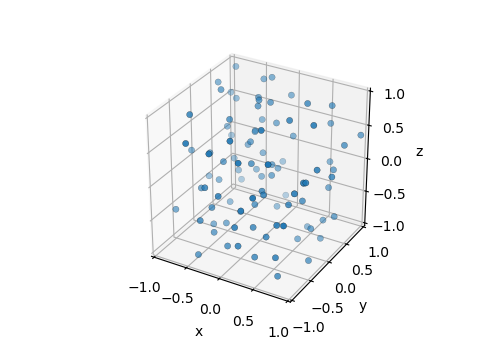

In [220]:
%matplotlib widget
rang2 = [-1, 1]
plot_3D(x, y, z, [rang2, rang2, rang2]);